# ADC Target Discovery: Biological Problem

**v0.1 educational notebook**

## Goal
Understand why ADC target prioritization is not equivalent to finding genes with high tumor expression. We use a small synthetic dataset to introduce tumor expression, normal expression, prevalence, heterogeneity, and surface eligibility.

**Data mode:** Synthetic educational example.

## Canonical guide

### Learning objectives
- Translate ADC target biology into measurable features.
- Distinguish tumor abundance, selectivity, prevalence, heterogeneity, and surface eligibility.
- Establish an interpretable baseline before using public data or machine learning.

### Data mode
Synthetic educational dataset generated inside the notebook.

### Inputs
None.

### Canonical outputs
No downstream dependency. This notebook is intentionally standalone.

### Scientific limitation
Synthetic scores are pedagogical constructs and are not biological or clinical measurements.

### Next step
Notebook 02 replaces the toy expression example with a TCGA/GTEx-style tumor–normal workflow.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

In [2]:
genes = ['TARGET_A','TARGET_B','TARGET_C','TARGET_D','TARGET_E','TARGET_F','TARGET_G','TARGET_H']
tumor = pd.DataFrame(rng.normal(5,1,(10,len(genes))), columns=genes)
normal = pd.DataFrame(rng.normal(1.5,0.6,(6,len(genes))), columns=genes)
# Intentional teaching patterns
tumor['TARGET_B'] = [0.5,0.8,1.0,8.0,8.5,0.7,7.5,0.6,8.2,0.4]  # heterogeneous
normal['TARGET_F'] = rng.normal(4.8,0.3,6)                        # normal-tissue burden
surface = {'TARGET_A':1,'TARGET_B':1,'TARGET_C':1,'TARGET_D':1,'TARGET_E':1,'TARGET_F':1,'TARGET_G':0,'TARGET_H':1}
features = pd.DataFrame(index=genes)
features['tumor_mean'] = tumor.mean()
features['normal_mean'] = normal.mean()
features['delta_expression'] = features.tumor_mean-features.normal_mean
features['tumor_prevalence'] = (tumor>4).mean()
features['tumor_sd'] = tumor.std()
features['surface_protein'] = pd.Series(surface)
features

,tumor_mean,normal_mean,delta_expression,tumor_prevalence,tumor_sd,surface_protein
TARGET_A,5.065490,1.206356,3.859134,1.0,0.584273,1
TARGET_B,3.620000,1.231514,2.388486,0.4,3.823843,1
TARGET_C,5.220807,1.504421,3.716386,1.0,0.641307,1
TARGET_D,5.522271,1.410496,4.111775,1.0,0.500344,1
TARGET_E,4.563630,1.491080,3.072551,0.7,0.943507,1
TARGET_F,4.826616,4.654005,0.172611,0.9,0.694803,1
TARGET_G,5.304877,1.598650,3.706227,0.9,1.005115,0
TARGET_H,4.764242,1.311251,3.452991,0.9,0.584689,1


A high tumor mean alone is insufficient. Target B illustrates heterogeneity; Target F illustrates normal-tissue burden; Target G illustrates a non-surface candidate.

In [3]:
def minmax(s):
    return (s-s.min())/(s.max()-s.min()) if s.max()>s.min() else pd.Series(0.5,index=s.index)
features['tumor_score']=minmax(features.tumor_mean)
features['selectivity_score']=minmax(features.delta_expression)
features['prevalence_score']=features.tumor_prevalence
features['heterogeneity_risk']=minmax(features.tumor_sd)
features['normal_risk']=minmax(features.normal_mean)
features['rule_score']=(0.25*features.tumor_score+0.30*features.selectivity_score+0.25*features.prevalence_score+0.20*features.surface_protein-0.10*features.heterogeneity_risk-0.10*features.normal_risk)
features.sort_values('rule_score',ascending=False)

,tumor_mean,normal_mean,delta_expression,tumor_prevalence,tumor_sd,surface_protein,tumor_score,selectivity_score,prevalence_score,heterogeneity_risk,normal_risk,rule_score
TARGET_D,5.522271,1.410496,4.111775,1.0,0.500344,1,1.000000,1.000000,1.0,0.000000,0.059211,0.994079
TARGET_A,5.065490,1.206356,3.859134,1.0,0.584273,1,0.759876,0.935864,1.0,0.025253,0.000000,0.918203
TARGET_C,5.220807,1.504421,3.716386,1.0,0.641307,1,0.841524,0.899626,1.0,0.042414,0.086455,0.917382
TARGET_H,4.764242,1.311251,3.452991,0.9,0.584689,1,0.601514,0.832760,0.9,0.025378,0.030425,0.819626
TARGET_E,4.563630,1.491080,3.072551,0.7,0.943507,1,0.496055,0.736182,0.7,0.133342,0.082585,0.698275
TARGET_G,5.304877,1.598650,3.706227,0.9,1.005115,0,0.885719,0.897047,0.9,0.151879,0.113786,0.688977
TARGET_F,4.826616,4.654005,0.172611,0.9,0.694803,1,0.634303,0.000000,0.9,0.058510,1.000000,0.477725
TARGET_B,3.620000,1.231514,2.388486,0.4,3.823843,1,0.000000,0.562524,0.4,1.000000,0.007297,0.368028


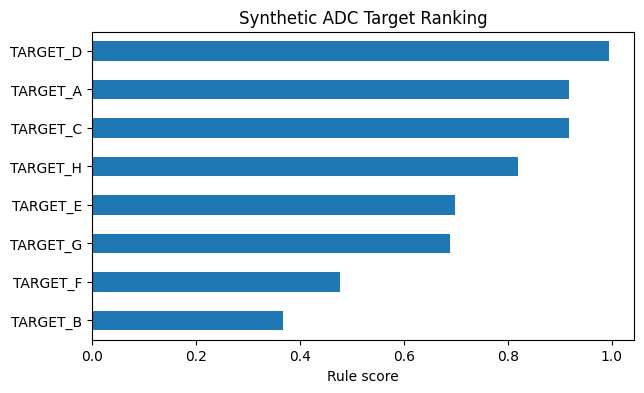

In [4]:
features.sort_values('rule_score').rule_score.plot.barh(figsize=(7,4), title='Synthetic ADC Target Ranking')
plt.xlabel('Rule score')
plt.show()

## Take-home message
Feature engineering is already a form of scientific modeling: biological assumptions are converted into measurable variables before any machine-learning model is trained.